# Model Training: Baseline and Uplift Models

This notebook implements:
1. **Baseline models**
   - Random targeting
   - Response model (predicts who will convert, ignoring treatment effect)
2. **Uplift models**
   - S-learner
   - T-learner

The models will be evaluated and compared using uplift-specific metrics (AUUC/Qini).

As discussed in the EDA notebook, this analysis will focus on comparing customers who received the men's email campaign to those who did not.

## Choice of Machine Learning Algorithms

The random targeting baseline will not use any machine learning algorithm. It will simply involve assigning a random score to each customer. For each of the response model baseline, S-learner, and T-learner, I will use two different machine learning algorithms:

1. Logistic Regression
2. LightGBM

Implementing a regression algorithm and an ensemble tree classifier for each model will enable robust comparison of their performance. I chose these two models because they complement each other well: Logistic Regression is simple, interpretable, and smooth, while LightGBM is more complex and has higher potential for accuracy, but also greater risk of overfitting.

I chose LightGBM over XGBoost primarily because of its speed. While the dataset is not large, I will implement multiple models and perform hyperparameter tuning for each. Given that, I want to use a model that runs quickly.

Additionally, LightGBM employs leaf-wise growth (as opposed to XGBoost's level-wise growth). This can create deeper, more complex trees that achieve better accuracy [1]. However, it can also lead to overfitting. That is why it will be helpful to compare it to Logistic Regression. If the Logistic Regression models consistently outperform the LightGBM models, it could be because the LightGBM models are overfitting.

In [1]:
%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install lightgbm
# Tell Jupyter to automatically reload modules before executing code (avoids having to manually reload every time I edit the evaluation
# metric functions or other source files)
%load_ext autoreload
%autoreload 2


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Load and Prepare Data

The first step is to load the processed dataset. I will also go ahead and specify the random state to ensure reproducibility, categorize the feature columns for future use, and create a binary feature indicating whether or not the customer received an email.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Necessary for handling the import of the evaluation metrics
import sys
sys.path.append("..")
from evaluation_metrics.display_uplift_metrics import display_uplift_metrics
from evaluation_metrics.print_response_model_stats import print_response_model_stats
from evaluation_metrics.print_classification_metrics import print_classification_metrics
from evaluation_metrics.print_uplift_model_stats import print_uplift_model_stats
from lightgbm import LGBMClassifier

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the processed dataset that was saved at the end of the EDA notebook
df = pd.read_csv("../data/processed/hillstrom_mens_campaign.csv")

# Define features, treatment, and outcome
FEATURE_COLS = ["recency", "history", "mens", "womens", "zip_code", "newbie", "channel"]
CATEGORICAL_COLS = ["zip_code", "channel"]
NUMERIC_COLS = ["recency", "history", "mens", "womens", "newbie"]

# Create binary treatment indicator (1 = received email, 0 = no email)
df["treatment"] = (df["segment"] == "Mens E-Mail").astype(int)

# Verify treatment coding
print("Treatment coding verification:")
print(df.groupby(["segment", "treatment"]).size())

Treatment coding verification:
segment      treatment
Mens E-Mail  1            21307
No E-Mail    0            21306
dtype: int64


## Train/Test Split

Below, I perform the train/test split on the dataset. This is a bit different from the typical train/test split because the low conversion rates seen in this dataset necessitate stratification. I want to make sure that I don't end up with a test set that has no conversions. I also want to make sure that the treatment and control groups are proportionally represented in both the training and test sets.

To do this, I create a stratification key that combines the conversion feature with the binary treatment feature I made above.

In [3]:
# Create stratification key combining treatment and outcome
df["strat_key"] = df["treatment"].astype(str) + "_" + df["conversion"].astype(str)

# Split features and target
X = df[FEATURE_COLS]
y = df["conversion"]
treatment = df["treatment"]

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X, y, treatment,
    test_size = 0.2,
    random_state = RANDOM_STATE,
    stratify = df["strat_key"]
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
# Confirm that there is proportional representation of the treatment and control groups in both the training and test sets
print(f"\nTraining set treatment distribution:\n{treatment_train.value_counts(normalize = True)}")
print(f"\nTest set treatment distribution:\n{treatment_test.value_counts(normalize = True)}")
# Confirm that training and test sets have similar conversion rates
print(f"\nTraining set conversion rate: {y_train.mean():.4f}")
print(f"Test set conversion rate: {y_test.mean():.4f}")

Training set: 34090 samples
Test set: 8523 samples

Training set treatment distribution:
treatment
0    0.5
1    0.5
Name: proportion, dtype: float64

Test set treatment distribution:
treatment
1    0.500059
0    0.499941
Name: proportion, dtype: float64

Training set conversion rate: 0.0091
Test set conversion rate: 0.0092


## One-Hot Encoding Categorical Variables

The dataset has two categorical variables: zip_code and channel. If I were only using LightGBM, one-hot encoding likely would not be necessary because, like XGBoost, LightGBM handles categorical variables well [2]. However, because I'm also using a Logistic Regression model, I will one-hot encode those categorical features.

The numeric variables are scaled reasonably, so they will be passed through as is.

In [4]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore"), CATEGORICAL_COLS),
        ("num", "passthrough", NUMERIC_COLS)
    ]
)

# Apply one-hot encoding to both training and test sets (use fit_transform only on training data because that is where the mapping is learned)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names for interpretability
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(CATEGORICAL_COLS).tolist()
feature_names = cat_feature_names + NUMERIC_COLS

print(f"Processed features ({len(feature_names)}): {feature_names}")
print(f"\nProcessed training shape: {X_train_processed.shape}")

Processed features (9): ['zip_code_Suburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web', 'recency', 'history', 'mens', 'womens', 'newbie']

Processed training shape: (34090, 9)


## Baseline Model 1: Random Targeting

The simplest possible baseline: assign each customer a random score. This represents the expected performance if all customers are targeted without any model at all.

In [5]:
random_scores_test = np.random.uniform(0, 1, size = len(X_test))

print("Random targeting baseline created.")
print(f"Score range: [{random_scores_test.min():.3f}, {random_scores_test.max():.3f}]")
print(f"Mean score: {random_scores_test.mean():.3f}")

Random targeting baseline created.
Score range: [0.000, 1.000]
Mean score: 0.494


## Baseline Model 2: Response Model

This model is a critical baseline for uplift modeling. It answers the question "which consumers are most likely to buy" by predicting conversion probability without accounting for the treatment effect.

**Hypothesis: This model is an inferior approach to customer targeting and will be outperformed by uplift models.**

### Justification for hypothesis:
- Some high-probability purchasers are likely to buy regardless of whether they receive the email, so targeting them is a waste of resources.
- Some low-probability purchasers might become much more likely to buy if they receive the email, so failing to target them could cause the company to miss out on significant gains.
- Thus, the response model fails to capture the incremental effect of the treatment, which is a significantly better measure of which customers should be targeted.

### Training approach:

The response model is trained only on the treatment group. This provides a fairer comparison than training on the entire dataset, because it simulates the real-world scenario in which only customers who received an email are observed. It also makes it cleaner to compare and contrast the response model with the uplift models.

### Addressing class imbalance:

As I discovered during the exploratory data analysis, the outcome feature in this dataset is significantly imbalanced. If that is not addressed, my models' results will have a limited signal, because they will likely just learn that they can achieve the best results by predicting 0 for every customer. To mitigate this imbalance, I will set the class_weight attribute to "balanced" for each of my models.

### Response Model Baseline - Logistic Regression

In [6]:
# Filter to treatment group only for response model training
treatment_mask_train = treatment_train == 1
X_train_treatment = X_train_processed[treatment_mask_train]
y_train_treatment = y_train[treatment_mask_train].values

print(f"Response model training set: {len(X_train_treatment)} samples (treatment group only)")
print(f"Conversion rate in training set: {y_train_treatment.mean():.4f}")

# Train response model
lr_response_model = LogisticRegression(
    random_state = RANDOM_STATE,
    max_iter = 1000,
    class_weight = "balanced"  # Necessary to address the imbalance of the conversion feature
)

lr_response_model.fit(X_train_treatment, y_train_treatment)

# Generate predictions on test set
# predict_proba returns [P(class=0), P(class=1)] so the indexing is necessary to get P(conversion = 1), which is what I'm trying to measure here
lr_response_scores_test = lr_response_model.predict_proba(X_test_processed)[:, 1]
lr_response_predictions_test = lr_response_model.predict(X_test_processed)

# Print some basic statistics about the model
print_response_model_stats(lr_response_scores_test, lr_response_predictions_test)

Response model training set: 17045 samples (treatment group only)
Conversion rate in training set: 0.0125
Score range: [0.2917, 0.8745]
Mean predicted probability: 0.4820
Predicted conversion rate: 0.3864


### Response Model Baseline - LightGBM Classifier

In [7]:
# Convert to dataframes with consistent feature names to suppress "does not have valid feature names" warning
X_train_treatment_df = pd.DataFrame(X_train_treatment, columns = feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns = feature_names)

lgbm_response_model = LGBMClassifier(
    random_state = RANDOM_STATE,
    class_weight = "balanced",
    verbose = -1
)

lgbm_response_model.fit(X_train_treatment_df, y_train_treatment)
lgbm_response_scores_test = lgbm_response_model.predict_proba(X_test_processed_df)[:, 1]
lgbm_response_predictions_test = lgbm_response_model.predict(X_test_processed_df)

print_response_model_stats(lgbm_response_scores_test, lgbm_response_predictions_test)

Score range: [0.0009, 0.9115]
Mean predicted probability: 0.2073
Predicted conversion rate: 0.1038


### Response Model Evaluation: Standard Metrics

Because the models I am implementing are uplift models, the metrics I primarily care about are AUUC and Qini, as these are the standard metrics for measuring uplift. Measuring uplift models using metrics such as accuracy and precision does not make sense because their outputs are not binary predictions. Instead, it is an estimated treatment effect: the difference in conversion probability with vs without treatment. 

In contrast, the output of the response models *is* a binary prediction, so it is possible to conduct a more standard analysis using metrics such as accuracy, precision, recall, F1 score, a confusion matrix, and feature importance. While the value of these metrics is limited by the inability to directly compare them to corresponding values generated by the uplift models, they still provide helpful information, so I will calculate them below.

**Note**: Although the response model was trained only on the treatment group, these metrics are computed on the whole test set. This is because I want to predict how well "who will convert if treated" predicts actual conversions across the entire population.

In [8]:
print_classification_metrics(lr_response_predictions_test, y_test, "Logistic Regression Response Model")
print("\n")
print_classification_metrics(lgbm_response_predictions_test, y_test, "LightGBM Response Model")

Logistic Regression Response Model Classification Metrics
Accuracy:  0.6146
Precision: 0.0131
Recall:    0.5513
F1 Score:  0.0255


LightGBM Response Model Classification Metrics
Accuracy:  0.8898
Precision: 0.0136
Recall:    0.1538
F1 Score:  0.0249


These metrics show that the LightGBM response model exhibits substantially higher accuracy but substantially lower recall than the Logistic Regression response model. This reflects a difference in how these two machine learning algorithms handle the class_weight = "balanced" setting. This setting tells the algorithms to penalize false negatives (missed conversions) more heavily. Because logistic regression is a simple linear model, it has limited ways to do this, so it simply shifts the decision boundary to become more liberal about predicting conversions. This reduces accuracy but increases the number of true positives, thereby increasing recall.

In contrast, LightGBM's more complex tree structure offers it more options for penalizing false negatives more heavily. It does not have to resort to shifting a global decision boundary. Instead, it has more flexibility to be aggressive with predicting conversions in some circumstances and conservative in others. This makes it more accurate than the Logistic Regression response model, but also means its recall is lower because it is not as aggressive overall when predicting conversions and thus does not end up predicting as many true positives.

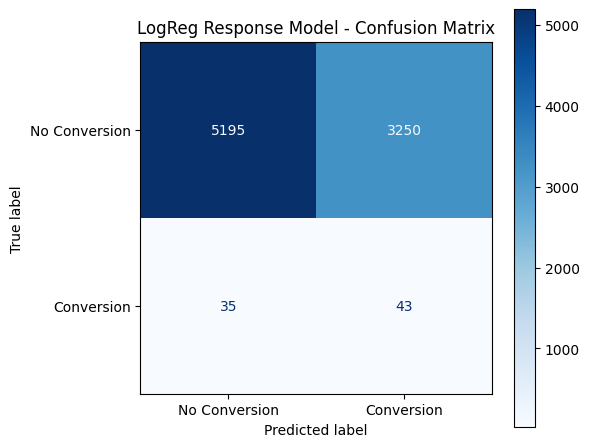


Logistic Regression Confusion Matrix Interpretation:
  True Negatives:  5,195 (correctly predicted no conversion)
  False Positives: 3,250 (predicted conversion, didn't convert)
  False Negatives: 35 (predicted no conversion, did convert)
  True Positives:  43 (correctly predicted conversion)


In [9]:
# LogReg confusion matrix visualization
fig, ax = plt.subplots(figsize = (6, 5))
cm = confusion_matrix(y_test, lr_response_predictions_test)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Conversion", "Conversion"])
disp.plot(ax = ax, cmap = "Blues")
ax.set_title("LogReg Response Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"\nLogistic Regression Confusion Matrix Interpretation:")
print(f"  True Negatives:  {cm[0,0]:,} (correctly predicted no conversion)")
print(f"  False Positives: {cm[0,1]:,} (predicted conversion, didn't convert)")
print(f"  False Negatives: {cm[1,0]:,} (predicted no conversion, did convert)")
print(f"  True Positives:  {cm[1,1]:,} (correctly predicted conversion)")

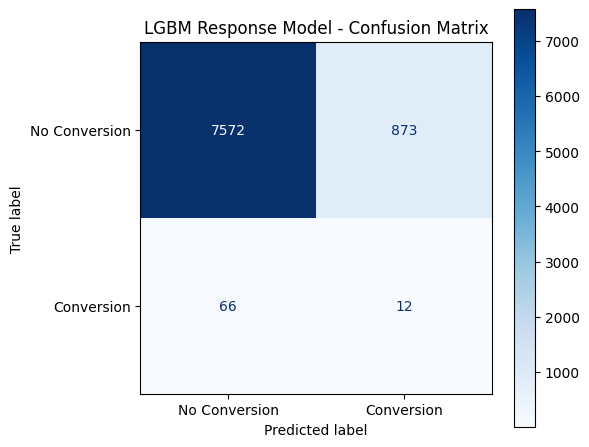


LightGBM Confusion Matrix Interpretation:
  True Negatives:  7,572 (correctly predicted no conversion)
  False Positives: 873 (predicted conversion, didn't convert)
  False Negatives: 66 (predicted no conversion, did convert)
  True Positives:  12 (correctly predicted conversion)


In [10]:
# LightGBM confusion matrix visualization
fig, ax = plt.subplots(figsize = (6, 5))
cm = confusion_matrix(y_test, lgbm_response_predictions_test)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Conversion", "Conversion"])
disp.plot(ax = ax, cmap = "Blues")
ax.set_title("LGBM Response Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"\nLightGBM Confusion Matrix Interpretation:")
print(f"  True Negatives:  {cm[0,0]:,} (correctly predicted no conversion)")
print(f"  False Positives: {cm[0,1]:,} (predicted conversion, didn't convert)")
print(f"  False Negatives: {cm[1,0]:,} (predicted no conversion, did convert)")
print(f"  True Positives:  {cm[1,1]:,} (correctly predicted conversion)")

The confusion matrices confirm the above observation that weight balancing makes the Logistic Regression response model much more aggressive in predicting conversions than the LightGBM response model. The Logistic Regression model predicted over three times as many conversions as the LightGBM model. This resulted in it having ~3.5 times as many true positives as the LightGBM model. However, it also resulted in lower accuracy. Because the Logistic Regression response model was so aggressive in predicting conversions, it made 3,285 incorrect predictions, compared with only 939 for the LightGBM model.

### Response Model Evaluation: Feature Importance

Next, I want to examine which features the response models consider most predictive of conversion.

Logistic Regression Response Model - Feature Coefficients (sorted by absolute value):
          feature  coefficient
             mens     0.586489
           womens     0.515910
           newbie    -0.378958
    channel_Phone    -0.275069
   zip_code_Urban    -0.203011
zip_code_Suburban    -0.071281
      channel_Web    -0.063358
          recency    -0.028341
          history     0.000649


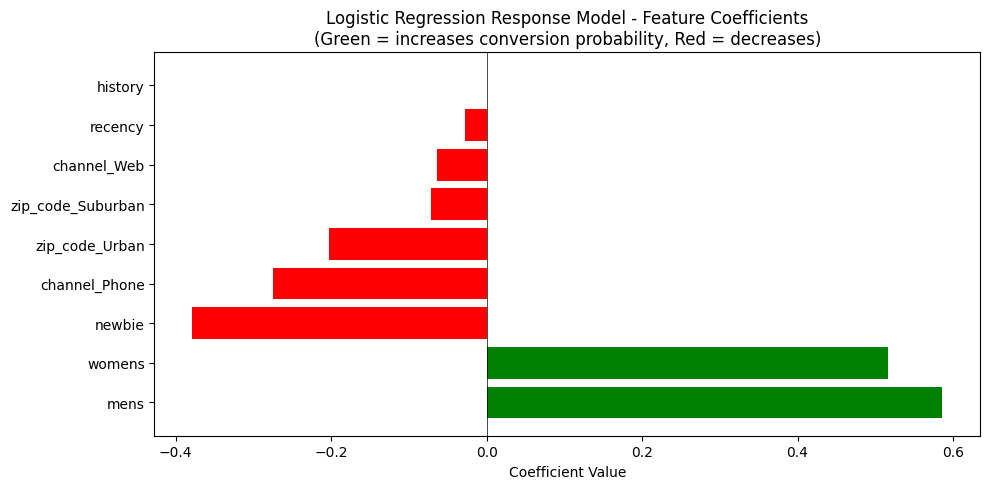

In [11]:
lr_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_response_model.coef_[0]
}).sort_values("coefficient", key = abs, ascending = False)

print("Logistic Regression Response Model - Feature Coefficients (sorted by absolute value):")
print(lr_coefficients.to_string(index = False))

fig, ax = plt.subplots(figsize = (10, 5))
colors = ["green" if c > 0 else "red" for c in lr_coefficients["coefficient"]]
ax.barh(lr_coefficients["feature"], lr_coefficients["coefficient"], color = colors)
ax.set_xlabel("Coefficient Value")
ax.set_title("Logistic Regression Response Model - Feature Coefficients\n(Green = increases conversion probability, Red = decreases)")
ax.axvline(x = 0, color = "black", linestyle = "-", linewidth = 0.5)
plt.tight_layout()
plt.show()

In [12]:
lgbm_coefficients = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm_response_model.feature_importances_
}).sort_values("importance", ascending=False)

print("LightGBM Response Model - Feature Importances:")
print(lgbm_coefficients.to_string(index=False))

LightGBM Response Model - Feature Importances:
          feature  importance
          history        1667
          recency         636
zip_code_Suburban         132
             mens         105
           newbie         105
    channel_Phone         101
   zip_code_Urban          95
      channel_Web          86
           womens          73


The feature importances of both response models indicate that recent purchases are essential for predicting customer conversion. However, they do so in different ways. The Logistic Regression model favors the mens and womens features, while the LightGBM model favors history and recency of last purchase. This is likely due to the algorithmic structure. Logistic Regression's linear structure means it favors binary features that cleanly separate groups. LightGBM's tree structure prefers continuous features that enable multiple split points. Notably, history has a near-zero coefficient in the Logistic Regression but dominates LightGBM importance, suggesting a non-linear relationship with conversion that tree-based models capture more effectively.

### Response Model Evaluation: Uplift Metrics

I also want to measure how the baseline models perform on the uplift metrics (Qini and AUUC).

**Hypothesis**: The random baseline should have a poor Qini value because it is just random targeting. The response model baselines may yield a slightly positive Qini if the likelihood of purchase correlates with persuadability, but the response models are not optimized for this. 

Baseline Models - Uplift Metrics

Random Targeting:
  AUUC: 11.74
  Qini: -3.25

Response Model (LogReg):
  AUUC: 20.47
  Qini: 5.47

Response Model (LightGBM):
  AUUC: 17.63
  Qini: 2.64


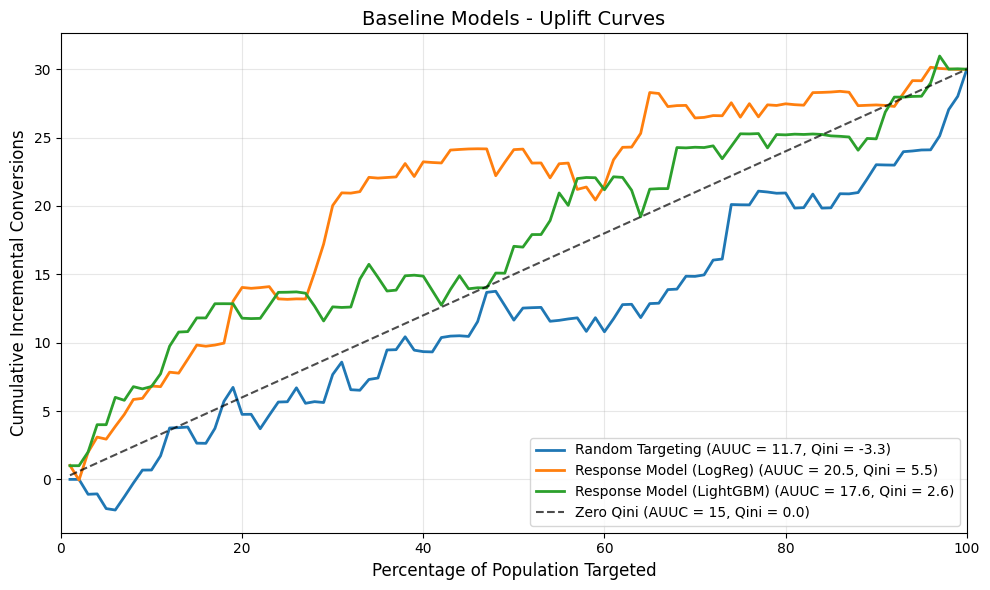

In [13]:
baseline_results = {
    "Random Targeting": random_scores_test,
    "Response Model (LogReg)": lr_response_scores_test,
    "Response Model (LightGBM)": lgbm_response_scores_test,
}

display_uplift_metrics(baseline_results, "Baseline Models", y_test, treatment_test)

As expected, the random targeting baseline performed poorly, with a Qini value that was actually less than 0. Also, as expected, the response models each had a small positive Qini, likely because, as my exploratory data analysis alluded to, the likelihood of making a purchase is correlated with persuadability. However, the small value indicates room for improvement through the use of uplift models.

Also noteworthy is the fact that the Logistic Regression response model outperforms the LightGBM response model. This is a bit surprising, as LightGBM is generally considered a stronger machine learning algorithm than Logistic Regression. However, as noted above, LightGBM models can suffer from overfitting, which may be causing the underperformance of the LightGBM response model. It will be interesting to see if a similar trend is evident when comparing the Logistic Regression and LightGBM uplift models.

NOTE: The dotted line on the uplift chart is the Qini baseline: the area under it represents a Qini of precisely 0. It is the area under the model curves that is compared when determining their Qini values.

## Store Baseline Results

The code below is intended to store baseline predictions for comparison with the uplift models.

In [14]:
results_df = pd.DataFrame({
    "y_true": y_test.values,
    "treatment": treatment_test.values,
    "random_score": random_scores_test,
    "response_score_lr": lr_response_scores_test,
    "response_score_lgbm": lgbm_response_scores_test
})

print("Results dataframe created with baseline scores.")
print(f"Shape: {results_df.shape}")
results_df.head(10)

Results dataframe created with baseline scores.
Shape: (8523, 5)


,y_true,treatment,random_score,response_score_lr,response_score_lgbm
0,0,1,0.374540,0.420715,0.024481
1,0,1,0.950714,0.386564,0.088468
2,0,1,0.731994,0.668775,0.281063
3,0,0,0.598658,0.345404,0.050571
4,0,0,0.156019,0.604837,0.563886
5,0,1,0.155995,0.493119,0.432014
6,0,1,0.058084,0.502046,0.154361
7,0,0,0.866176,0.523645,0.051062
8,0,0,0.601115,0.396213,0.070078
9,0,0,0.708073,0.555308,0.819622


## Summary

Three baseline models have been implemented above:

| Model | Description | Use Case |
|-------|-------------|----------|
| **Random** | Uniform random scores | Lower bound (any useful model should beat this) |
| **Response (LogReg)** | P(conversion \| features) trained on treatment group using Logistic Regression algorithm| Traditional targeting approach (target customers who are most likely to buy, regardless of persuadability) |
| **Response (LightGBM)** | P(conversion \| features) trained on treatment group using LightGBM algorithm| Traditional targeting approach (target customers who are most likely to buy, regardless of persuadability) |

### Key Insight

The response model tells us who is likely to convert, but not who will convert *because* of the treatment. 

Consider two customers:
- **Customer A**: 80% likely to convert, will buy regardless of email.
- **Customer B**: 20% likely to convert without email, 40% with email.

The response model ranks Customer A higher, but Customer B has a higher uplift (20 percentage points vs 0). Targeting Customer B is the better use of the marketing budget.

# Model Training: S-Learner

The code below instantiates and trains both the Logistic Regression S-learner and the LightGBM S-Learner. It then uses the test data to predict the probability of conversion under two scenarios:

1. The scenario where every customer is treated (receives an email).
2. The scenario where every customer is in the control group (i.e., no customer receives an email).

It then calculates the uplift, which is P(conversion | treated) - P(conversion | control), and displays some basic metrics for the model. Note that the basic metrics printed for the uplift models differ slightly from those for the response models. This is mainly because the uplift models are not predictors, so calculating metrics like predicted conversion rates does not work. Instead, for uplift models, I am more interested in things like mean estimated uplift.

Displaying and analyzing the Qini and AUUC in comparison to the baseline models is saved until after the T-Learners are implemented.

In [15]:
s_learner_features = feature_names + ["treatment"]

# Add treatment as a column to training features
X_train_with_treatment = pd.DataFrame(
    np.column_stack([X_train_processed, treatment_train.values]),
    columns = s_learner_features
)

# Create test sets with treatment = 1 and treatment = 0 for all customers
X_test_treated = pd.DataFrame(
    np.column_stack([X_test_processed, np.ones(len(X_test_processed))]),
    columns = s_learner_features
)
X_test_control = pd.DataFrame(
    np.column_stack([X_test_processed, np.zeros(len(X_test_processed))]),
    columns = s_learner_features
)

s_learner_lr = LogisticRegression(
    random_state = RANDOM_STATE,
    max_iter = 1000,
    class_weight = "balanced"  
)

s_learner_lr.fit(X_train_with_treatment, y_train)

s_learner_lr_scores_test_treatment = s_learner_lr.predict_proba(X_test_treated)[:, 1]
s_learner_lr_scores_test_control = s_learner_lr.predict_proba(X_test_control)[:, 1]

s_learner_lr_uplift = s_learner_lr_scores_test_treatment - s_learner_lr_scores_test_control

# Print the uplift score range, mean estimated uplift, and number of customers with positive uplift
print_uplift_model_stats(s_learner_lr_uplift)

Uplift score range: [0.0713, 0.2070]
Mean estimated uplift: 0.1946
Customers with positive uplift: 100.0%


In [16]:
s_learner_lgbm = LGBMClassifier(
    random_state = RANDOM_STATE,
    class_weight = "balanced",
    verbose = -1
)

s_learner_lgbm.fit(X_train_with_treatment, y_train)

# Predict P(conversion) under each scenario (treatment = 1 for all customers and treatment = 0 for all customers)
s_prob_treated = s_learner_lgbm.predict_proba(X_test_treated)[:, 1]
s_prob_control = s_learner_lgbm.predict_proba(X_test_control)[:, 1]

# Uplift = P(conversion | treated) - P(conversion | control)
s_learner_lgbm_uplift = s_prob_treated - s_prob_control

print_uplift_model_stats(s_learner_lgbm_uplift)

Uplift score range: [-0.4327, 0.8202]
Mean estimated uplift: 0.1755
Customers with positive uplift: 91.8%


# Model Training: T-Learner

The code below instantiates and trains both the Logistic Regression T-learner and the LightGBM T-Learner. Each T-Learner actually uses two models: one for treatment and one for control. It then subtracts the control results from the treatment results to calculate the uplift.

In [17]:
# Create a control-only version of the training data similar to the treatment-only version created in connection with
# the LightGBM response model
control_mask = treatment_train == 0

# Note: No need to merge the treatment column with the other features here, because unlike with the
# S-Learner, the treatment information is captured by which model is being used (treatment or control)
X_train_control = X_train_processed[control_mask]
y_train_control = y_train[control_mask]

t_learner_lr_treatment = LogisticRegression(
    random_state = RANDOM_STATE,
    max_iter = 1000,
    class_weight = "balanced" 
)
t_learner_lr_control = LogisticRegression(
    random_state = RANDOM_STATE,
    max_iter = 1000,
    class_weight = "balanced"  
)

t_learner_lr_treatment.fit(X_train_treatment, y_train_treatment)
t_learner_lr_control.fit(X_train_control, y_train_control)

prob_treated_lr = t_learner_lr_treatment.predict_proba(X_test_processed)[:, 1]
prob_control_lr = t_learner_lr_control.predict_proba(X_test_processed)[:, 1]

t_learner_lr_uplift = prob_treated_lr - prob_control_lr

print_uplift_model_stats(t_learner_lr_uplift)

Uplift score range: [-0.2346, 0.3414]
Mean estimated uplift: 0.0425
Customers with positive uplift: 64.0%


In [18]:
X_train_control_df = pd.DataFrame(X_train_control, columns = feature_names)

# Create two different LightGBM models, one for treatment and one for control
t_learner_lgbm_treatment = LGBMClassifier(
    random_state = RANDOM_STATE,
    class_weight = "balanced",
    verbose = -1
)
t_learner_lgbm_control = LGBMClassifier(
    random_state = RANDOM_STATE,
    class_weight = "balanced",
    verbose = -1
)

# Use the dataframe versions of X_train_treatment, X_train_control, and X_test_processed to suppress feature name warning
t_learner_lgbm_treatment.fit(X_train_treatment_df, y_train_treatment)
t_learner_lgbm_control.fit(X_train_control_df, y_train_control)

prob_treated_lgbm = t_learner_lgbm_treatment.predict_proba(X_test_processed_df)[:, 1]
prob_control_lgbm = t_learner_lgbm_control.predict_proba(X_test_processed_df)[:, 1]

t_learner_lgbm_uplift = prob_treated_lgbm - prob_control_lgbm

print_uplift_model_stats(t_learner_lgbm_uplift)

Uplift score range: [-0.8920, 0.8907]
Mean estimated uplift: 0.1168
Customers with positive uplift: 80.8%


# Evaluation and Analysis

The code below displays the AUUC and Qini results for all models:


Initial Models - Uplift Metrics

Random Targeting:
  AUUC: 11.74
  Qini: -3.25

Response Model (LogReg):
  AUUC: 20.47
  Qini: 5.47

Response Model (LGBM):
  AUUC: 17.63
  Qini: 2.64

S-Learner (LogReg):
  AUUC: 13.75
  Qini: -1.25

S-Learner (LGBM):
  AUUC: 13.66
  Qini: -1.34

T-Learner (LogReg):
  AUUC: 12.45
  Qini: -2.54

T-Learner (LGBM):
  AUUC: 18.51
  Qini: 3.51


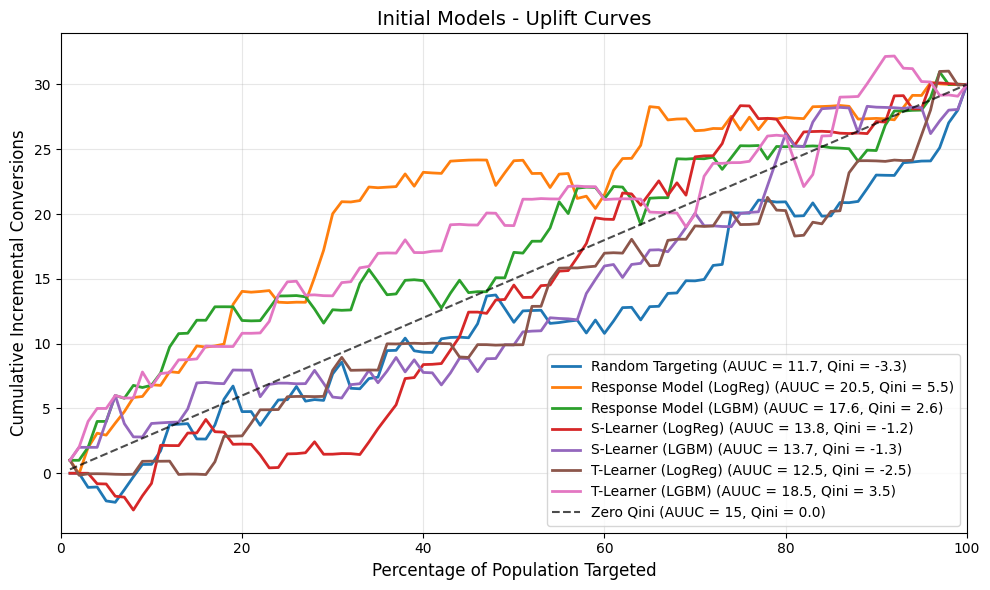

In [19]:
full_results = {
    "Random Targeting": random_scores_test,
    "Response Model (LogReg)": lr_response_scores_test,
    "Response Model (LGBM)": lgbm_response_scores_test,
    "S-Learner (LogReg)": s_learner_lr_uplift,
    "S-Learner (LGBM)": s_learner_lgbm_uplift,
    "T-Learner (LogReg)": t_learner_lr_uplift,
    "T-Learner (LGBM)": t_learner_lgbm_uplift
}

display_uplift_metrics(full_results, "Initial Models", y_test, treatment_test)

The final ranking of all models based on AUUC/Qini is as follows:

| Rank | Model | AUUC/Qini |
|-------|-------------|----------|
| 1 | Response Model (LogReg) |  20.5/5.5  |
| 2 | T-Learner (LGBM)        |  18.5/3.5  |
| 3 | Response Model (LGBM)   |  17.6/2.6  |
| 4 | S-Learner (LogReg)      |  13.8/-1.2 |
| 5 | S-Learner (LGBM)        |  13.7/-1.3 |
| 6 | T-Learner (LogReg)      |  12.5/-2.5 |
| 7 | Random Targeting        |  11.7/-3.3 |

The highest performing model was the Logistic Regression response model. This contradicts my hypothesis and is a surprising result, given that Logistic Regression is generally considered a less powerful algorithm, and the response model does not account for persuadability. This could be due to the LightGBM models overfitting to the training data. However, the LightGBM response model also performed well. It could simply be that the response model’s baseline is a strong predictor of uplift in this dataset. It will be interesting to see whether hyperparameter tuning (particularly regularization) enables LightGBM models to surpass Logistic Regression models.

Although it did not outperform the Logistic Regression response model, the LightGBM T-Learner did produce strong results, outperforming every other model. It substantially outperformed both S-Learner models. Additionally, it showed the widest score range, indicating substantial heterogeneity in treatment effects. This, combined with its 81% positive uplift rate and strong Qini score, suggests it is successfully identifying persuadable customers while also flagging some who may respond negatively to treatment. With some hyperparameter tuning, it could ultimately turn out to be the strongest model.

The subpar performance of the S-Learner models likely indicates that treatment was less predictive of conversion than other features. Because S-Learners treat treatment as another feature, if treatment is less predictive than other features, the S-Learner will tend to focus on the more predictive features and will not adequately reflect the effects of treatment. This is why T-Learners are favored when treatment is less predictive than other features: they can capture information about the impact of treatment that is lost to the S-Learner [4].

That said, the poor performance of the Logistic Regression T-Learner is more puzzling. While it is not surprising that LightGBM models outperformed a Logistic Regression model, it is surprising that the Logistic Regression T-Learner was outperformed by other Logistic Regression models, particularly given the strong performance of the LightGBM T-Learner. This model shows a narrow score range and the lowest mean uplift, with only 64% of customers showing positive uplift. This suggests it may lack the flexibility to capture treatment-effect heterogeneity. Perhaps hyperparameter tuning can improve its performance.

Not surprisingly, the random-targeting baseline was the lowest-performing model.

# Next Steps

Implement cross-validation and hyperparameter tuning, and examine how that affects model performance. Before moving on, save the models, scores, and train/test split for use in the optimization phase:

In [20]:
import joblib
import os

# Create directory for saved objects
os.makedirs("../models", exist_ok = True)

# Save the train/test split data
split_data = {
    "X_train_processed": X_train_processed,
    "X_test_processed": X_test_processed,
    "y_train": y_train,
    "y_test": y_test,
    "treatment_train": treatment_train,
    "treatment_test": treatment_test,
    "feature_names": feature_names
}
joblib.dump(split_data, "../models/train_test_split.joblib")

# Save untuned models
untuned_models = {
    "lr_response": lr_response_model,
    "lgbm_response": lgbm_response_model,
    "s_learner_lr": s_learner_lr,
    "s_learner_lgbm": s_learner_lgbm,
    "t_learner_lr_treatment": t_learner_lr_treatment,
    "t_learner_lr_control": t_learner_lr_control,
    "t_learner_lgbm_treatment": t_learner_lgbm_treatment,
    "t_learner_lgbm_control": t_learner_lgbm_control
}
joblib.dump(untuned_models, "../models/untuned_models.joblib")

# Save untuned scores for comparison
untuned_scores = {
    "Random": random_scores_test,
    "Response (LogReg)": lr_response_scores_test,
    "Response (LGBM)": lgbm_response_scores_test,
    "S-Learner (LogReg)": s_learner_lr_uplift,
    "S-Learner (LGBM)": s_learner_lgbm_uplift,
    "T-Learner (LogReg)": t_learner_lr_uplift,
    "T-Learner (LGBM)": t_learner_lgbm_uplift
}
joblib.dump(untuned_scores, "../models/untuned_scores.joblib")

print("All models and data saved to ../models/")

All models and data saved to ../models/


# Sources

[1] Saha, S. (2025). *XGBoost vs LightGBM: How Are They Different*. Neptune Labs. https://neptune.ai/blog/xgboost-vs-lightgbm#:~:text=Structural%20differences%20between%20XGBoost%20and,utilization%20of%20two%20novel%20techniques:.

[2] Xu, Y. (2024). *How does LightGBM Handle Categorical Features with High Cardinality*. https://medium.com/@YanAIx/how-does-lightgbm-handle-categorical-features-with-high-cardinality-381fb06e7cc1.

[3] Kunzel, S., et. al. (2019). *Meta-learners for Estimating Heterogeneous Treatment Effects using Machine Learning*. https://arxiv.org/pdf/1706.03461.

[4] Alves, M. (2022). *21 - Meta Learners*. https://matheusfacure.github.io/python-causality-handbook/21-Meta-Learners.html#:~:text=might%20work%20better.-,Key%20Ideas,entire%20chapter%20dedicated%20to%20it.